# Latent → Feature Mapping: Load Saved Scores and Reconstruct the Visualisation

`07_attribution_vis_all.py`'s `plot_latent_feature_mapping` (reused as-is by `07b_cross_dataset_attribution_vis.py`)
correlates each model's latent dimensions against kinetic curve features (Spearman, MI, cosine similarity),
combines them into one score, and draws a figure showing only the top-N latents whose best-matching feature
is unique. When called with `return_scores=True`, it ALSO returns every `(branch, latent_rank, feature)`
triple's raw scores plus the saliency profiles needed to redraw the figure — not just the winning feature per
latent that ends up in the PNG. The pipeline (`run_interpretation_pipeline` in 07, `run_fold` in 07b) saves
this as a joblib bundle alongside the existing PNGs.

This notebook shows how to:
1. Load that saved joblib bundle (`{"scores": DataFrame, "profiles": DataFrame, "curve_meta": dict}`).
2. Explore the full correlation table directly — e.g. "what was the 2nd/3rd best feature for this latent"
   without rerunning anything.
3. Reconstruct the exact same PNG by rebuilding the `sections` structure `plot_latent_feature_mapping` uses
   internally, then calling the same `render_latent_feature_mapping_figure` the live pipeline calls —
   no model inference, no GPU, no rerun.

**Known limitation:** the saved bundle does not persist the raw kinetic feature matrix (`feat_matrix`), so
the reconstructed figure omits the one minor visual detail that depends on it — the dotted vertical
"best-match timestamp" marker line drawn only for timing-type features. Everything else (curves, saliency
overlay, score bars, star annotation, legend, colorbar) reconstructs exactly.

In [1]:
import os

try:
    # VS Code injects '__vsc_ipynb_file__' into the globals automatically
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        notebook_dir = os.path.dirname(notebook_path)
        os.chdir(notebook_dir)
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
%matplotlib inline

Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
import sys
import importlib.util
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, 'utils/model_training')
import config

# Import 07's module by file path (it starts with a digit, so it isn't a valid
# `import` target) -- same approach 07b itself uses to reuse 07's functions.
_spec = importlib.util.spec_from_file_location('attrib07', '07_attribution_vis_all.py')
attrib07 = importlib.util.module_from_spec(_spec)
sys.argv = ['notebook']  # 07's module-level code reads sys.argv in some helpers; keep it harmless
_spec.loader.exec_module(attrib07)

render_latent_feature_mapping_figure = attrib07.render_latent_feature_mapping_figure


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 1. Locate and load a saved scores+profiles+curve_meta bundle

- **07** (single experiment): `{exp_folder}/model_interpretation/{exp_name}/latent_feature_scores.joblib`
  (one file per experiment, accumulating across every `--filter_key`/`--curve_type` you've run with `07`).
- **07b** (cross-dataset LOFO): `{exp_folder}/cross_dataset_cv/{group_name}/model_interpretation/{fold_label}/latent_feature_scores_{curve_type}.joblib`
  (one file per fold **and** curve_type — curve_type is in the filename, not just a column, because
  concurrent SLURM array tasks can process the same fold with different curve_types).

Set `SCORES_PATH` below to whichever one you want to inspect.

In [3]:
config.MULTI_EXP_FOLDER

'/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi'

In [4]:
EXP_FOLDER = config.MULTI_EXP_FOLDER + "_nc_subtract"
# EXP_NAME = "D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08"  # e.g. one of os.listdir(EXP_FOLDER)
EXP_NAME = "D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08" 

SCORES_PATH = Path(EXP_FOLDER) / f"cross_dataset_cv/init_oneplex_nc_subtract/model_interpretation/lofo_{EXP_NAME}/latent_feature_scores.joblib"
print(SCORES_PATH)

/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi_nc_subtract/cross_dataset_cv/init_oneplex_nc_subtract/model_interpretation/lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08/latent_feature_scores.joblib


In [5]:
EXP_FOLDER = config.MULTI_EXP_FOLDER + "_nc_subtract"
# EXP_NAME = "D20260609_E00_C00_F4500KHz_U_norm_temp_ready_08"  # e.g. one of os.listdir(EXP_FOLDER)
EXP_NAME = "D20260609_E00_C00_F4500KHz_U_norm_temp_read_07" 

SCORES_PATH = Path(EXP_FOLDER) / f"cross_dataset_cv/init_oneplex_nc_subtract/model_interpretation/lofo_{EXP_NAME}/latent_feature_scores_ori_curve_avg.joblib"
print(SCORES_PATH)

bundle = joblib.load(SCORES_PATH)
scores_df = bundle["scores"]
profiles_df = bundle["profiles"]
curve_meta = bundle["curve_meta"]   # dict keyed by curve_type

print(f"scores: {len(scores_df)} rows, profiles: {len(profiles_df)} rows")
print("curve_types available:", list(curve_meta.keys()))
print("models available:", sorted(scores_df['model_name'].unique()))
print("filters available:", sorted(scores_df['filter_key'].unique()))
scores_df.head()

/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi_nc_subtract/cross_dataset_cv/init_oneplex_nc_subtract/model_interpretation/lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_read_07/latent_feature_scores_ori_curve_avg.joblib
scores: 9588 rows, profiles: 35 rows
curve_types available: ['ori_curve_avg']
models available: ['bigru', 'cnn', 'cnn_gru_dual', 'cnn_trans_dual', 'transformer']
filters available: ['none']


,branch,latent_rank,latent_index,feature,spearman,spearman_valid,mi,mi_raw,mi_valid,cosine,...,is_best_feature,kept_in_plot,w_spearman,w_mi,w_cosine,model_name,filter_key,curve_type,group_name,fold_label
0,single,1,1898,Ct,0.044090,True,0.334147,0.484082,True,0.094989,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
1,single,1,1898,lag_time,0.435250,True,0.197530,0.286164,True,0.046296,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
2,single,1,1898,xms,0.062738,True,0.199895,0.289590,True,0.041761,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
3,single,1,1898,xe,0.018221,True,0.022868,0.033128,True,0.100106,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
4,single,1,1898,rise_time_10_90,0.112940,True,0.334257,0.484241,True,0.037800,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...


In [6]:
scores_df.columns

Index(['branch', 'latent_rank', 'latent_index', 'feature', 'spearman',
       'spearman_valid', 'mi', 'mi_raw', 'mi_valid', 'cosine', 'combined',
       'feature_rank_for_latent', 'is_best_feature', 'kept_in_plot',
       'w_spearman', 'w_mi', 'w_cosine', 'model_name', 'filter_key',
       'curve_type', 'group_name', 'fold_label'],
      dtype='object')

## 2. Explore the raw correlation table directly

Every `(model, filter, curve_type, branch, latent_rank, feature)` combination is here — not just the
winning feature per latent that made it into the PNG. `feature_rank_for_latent` is precomputed (1=best),
so "what was the 2nd/3rd best feature for this latent" is a one-line filter, no re-deriving ranks yourself.

`combined` should always reconstruct from `spearman`/`mi`/`cosine` + the stored weights — useful as a
sanity check that you're reading the table correctly:
`combined == w_spearman*spearman + w_mi*mi + w_cosine*cosine` (NaNs treated as 0, matching the original
computation's skip-on-invalid behaviour).

In [7]:
MODEL = scores_df['model_name'].iloc[0]
FILTER = scores_df['filter_key'].iloc[0]
CURVE_TYPE = scores_df['curve_type'].iloc[0]

one_run = scores_df[
    (scores_df.model_name == MODEL) & (scores_df.filter_key == FILTER) & (scores_df.curve_type == CURVE_TYPE)
]

# Top 5 features (not just the winner) for the single most important latent of each branch.
for branch in sorted(one_run['branch'].unique()):
    top_latent = one_run[(one_run.branch == branch) & (one_run.latent_rank == 1)]
    print(f"\n--- branch={branch}, latent_rank=1 (the single most important latent) ---")
    display(
        top_latent.sort_values('feature_rank_for_latent')
        [['feature', 'feature_rank_for_latent', 'combined', 'spearman', 'mi', 'mi_raw', 'cosine', 'is_best_feature']]
        .head(100)
    )


--- branch=single, latent_rank=1 (the single most important latent) ---


,feature,feature_rank_for_latent,combined,spearman,mi,mi_raw,cosine,is_best_feature
11,auc_norm,1,0.534226,0.775195,0.928508,1.345138,0.076952,True
8,amplitude,2,0.409034,0.781737,0.396168,0.573932,0.090960,False
5,dy_xms,3,0.375205,0.714152,0.375757,0.544362,0.078283,False
10,y_xms,4,0.327885,0.576744,0.421197,0.610191,0.051814,False
13,snr_peak,5,0.284113,0.594172,0.280460,0.406305,0.015095,False
1,lag_time,6,0.220238,0.435250,0.197530,0.286164,0.046296,False
12,area_asymmetry_index,7,0.203558,0.354849,0.205887,0.298270,0.069723,False
16,overshoot_index,8,0.187581,0.316454,0.297932,0.431616,0.005847,False
4,rise_time_10_90,9,0.138213,0.112940,0.334257,0.484241,0.037800,False
0,Ct,10,0.136964,0.044090,0.334147,0.484082,0.094989,False


In [8]:
one_run[one_run.latent_rank == 20].sort_values("cosine", ascending=False).head(10)

,branch,latent_rank,latent_index,feature,spearman,spearman_valid,mi,mi_raw,mi_valid,cosine,...,is_best_feature,kept_in_plot,w_spearman,w_mi,w_cosine,model_name,filter_key,curve_type,group_name,fold_label
337,single,20,5,baseline_slope,0.170467,True,0.017934,0.025981,True,0.406357,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
324,single,20,5,lag_time,0.069946,True,0.055447,0.080326,True,0.263776,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
332,single,20,5,baseline_mean,0.760543,True,0.414730,0.600823,True,0.255582,...,True,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
336,single,20,5,snr_peak,0.163507,True,0.062841,0.091038,True,0.216067,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
326,single,20,5,xe,0.000838,True,0.042535,0.061621,True,0.127004,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
331,single,20,5,amplitude,0.185566,True,0.012739,0.018454,True,0.103118,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
329,single,20,5,max_accel,0.001698,True,0.013153,0.019054,True,0.099149,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
335,single,20,5,area_asymmetry_index,0.163145,True,0.018897,0.027377,True,0.092139,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
328,single,20,5,dy_xms,0.202646,True,0.048650,0.070480,True,0.089223,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
330,single,20,5,min_accel,0.017188,True,0.024495,0.035486,True,0.088930,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...


In [9]:
one_run[one_run.latent_rank == 20].sort_values("combined", ascending=False).head(10)

,branch,latent_rank,latent_index,feature,spearman,spearman_valid,mi,mi_raw,mi_valid,cosine,...,is_best_feature,kept_in_plot,w_spearman,w_mi,w_cosine,model_name,filter_key,curve_type,group_name,fold_label
332,single,20,5,baseline_mean,0.760543,True,0.414730,0.600823,True,0.255582,...,True,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
337,single,20,5,baseline_slope,0.170467,True,0.017934,0.025981,True,0.406357,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
333,single,20,5,y_xms,0.421309,True,0.111919,0.162138,True,0.053192,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
336,single,20,5,snr_peak,0.163507,True,0.062841,0.091038,True,0.216067,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
334,single,20,5,auc_norm,0.318368,True,0.028621,0.041464,True,0.079140,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
324,single,20,5,lag_time,0.069946,True,0.055447,0.080326,True,0.263776,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
339,single,20,5,overshoot_index,0.265181,True,0.184031,0.266607,True,0.002894,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
328,single,20,5,dy_xms,0.202646,True,0.048650,0.070480,True,0.089223,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
323,single,20,5,Ct,0.222801,True,0.053886,0.078066,True,0.066220,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...
331,single,20,5,amplitude,0.185566,True,0.012739,0.018454,True,0.103118,...,False,True,0.35,0.25,0.4,cnn,none,ori_curve_avg,init_oneplex_nc_subtract,lofo_D20260609_E00_C00_F4500KHz_U_norm_temp_re...


In [10]:
# Sanity check: combined reconstructs from the raw metrics + stored weights.
recon = (
    one_run['w_spearman'] * one_run['spearman'].fillna(0)
    + one_run['w_mi'] * one_run['mi'].fillna(0)
    + one_run['w_cosine'] * one_run['cosine']
)
max_err = (recon - one_run['combined']).abs().max()
print(f"max reconstruction error: {max_err:.2e}")

max reconstruction error: 0.00e+00


## 3. Reconstruct the exact figure

`render_latent_feature_mapping_figure` is the same function the live pipeline calls — it just needs the
`sections` structure `plot_latent_feature_mapping` builds internally (one dict per branch: label, the kept
latents' original ranks/flat indices, their saliency profiles, and the full `(k, n_feats)` combined-score
matrix). `rebuild_sections` below reconstructs that structure from `scores_df`/`profiles_df` — filtering to
`kept_in_plot == True` rows (the figure never shows anything else), pivoting scores into the matrix shape,
and pulling saliency profiles from the profiles table.

In [11]:
def rebuild_sections(scores_df, profiles_df, feat_names, model_name, filter_key, curve_type,
                      group_name=None, fold_label=None):
    """Rebuilds plot_latent_feature_mapping's `sections` list from the saved tables,
    for one (model, filter, curve_type[, group, fold]) combination.

    feat_names must be the SAME ordered list used by the original run (curve_meta's
    "feat_names" entry for this curve_type) -- it controls the score-bar x-axis order
    and feature-group colour-coding, and only contains the "valid" (>=5 finite values)
    features the original run actually scored.

    Builds the "spearman"/"mi"/"cosine" matrices alongside "combined" (not just the
    winning feature per latent) so render_latent_feature_mapping_figure's `metric=`
    parameter can switch which one drives the bar chart -- mirrors the live pipeline's
    own section dict (plot_latent_feature_mapping), which stores all four for the same
    reason. NaN-valid (spearman_valid/mi_valid False) entries default to 0, matching
    how the live computation leaves them at their zero-initialized default.
    """
    mask_s = (
        (scores_df.model_name == model_name) & (scores_df.filter_key == filter_key)
        & (scores_df.curve_type == curve_type) & (scores_df.kept_in_plot)
    )
    mask_p = (
        (profiles_df.model_name == model_name) & (profiles_df.filter_key == filter_key)
        & (profiles_df.curve_type == curve_type)
    )
    if group_name is not None:
        mask_s &= (scores_df.group_name == group_name)
        mask_p &= (profiles_df.group_name == group_name)
    if fold_label is not None:
        mask_s &= (scores_df.fold_label == fold_label)
        mask_p &= (profiles_df.fold_label == fold_label)

    sub_s, sub_p = scores_df[mask_s], profiles_df[mask_p]
    feat_to_idx = {f: i for i, f in enumerate(feat_names)}

    sections = []
    for branch in sorted(sub_s['branch'].unique()):
        bs = sub_s[sub_s.branch == branch]
        bp = sub_p[sub_p.branch == branch].set_index('latent_rank')
        true_ranks = sorted(bs['latent_rank'].unique())
        k = len(true_ranks)

        order = np.array([bp.loc[r, 'latent_index'] for r in true_ranks])
        sal_profiles = np.array([bp.loc[r, 'sal_profile'] for r in true_ranks])

        combined = np.zeros((k, len(feat_names)))
        spearman = np.zeros((k, len(feat_names)))
        mi       = np.zeros((k, len(feat_names)))
        cosine   = np.zeros((k, len(feat_names)))
        best_feat_idx = np.zeros(k, dtype=int)
        for i, r in enumerate(true_ranks):
            for _, row in bs[bs.latent_rank == r].iterrows():
                j = feat_to_idx[row['feature']]
                combined[i, j] = row['combined']
                spearman[i, j] = 0.0 if pd.isna(row['spearman']) else row['spearman']
                mi[i, j]       = 0.0 if pd.isna(row['mi']) else row['mi']
                cosine[i, j]   = row['cosine']
                if row['is_best_feature']:
                    best_feat_idx[i] = j
        best_score = combined[np.arange(k), best_feat_idx]

        sections.append({
            "label": None if branch == "single" else branch,
            "order": order, "k": k, "true_ranks": true_ranks,
            "sal_profiles": sal_profiles, "combined": combined,
            "spearman": spearman, "mi": mi, "cosine": cosine,
            "best_feat_idx": best_feat_idx, "best_score": best_score,
        })
    return sections

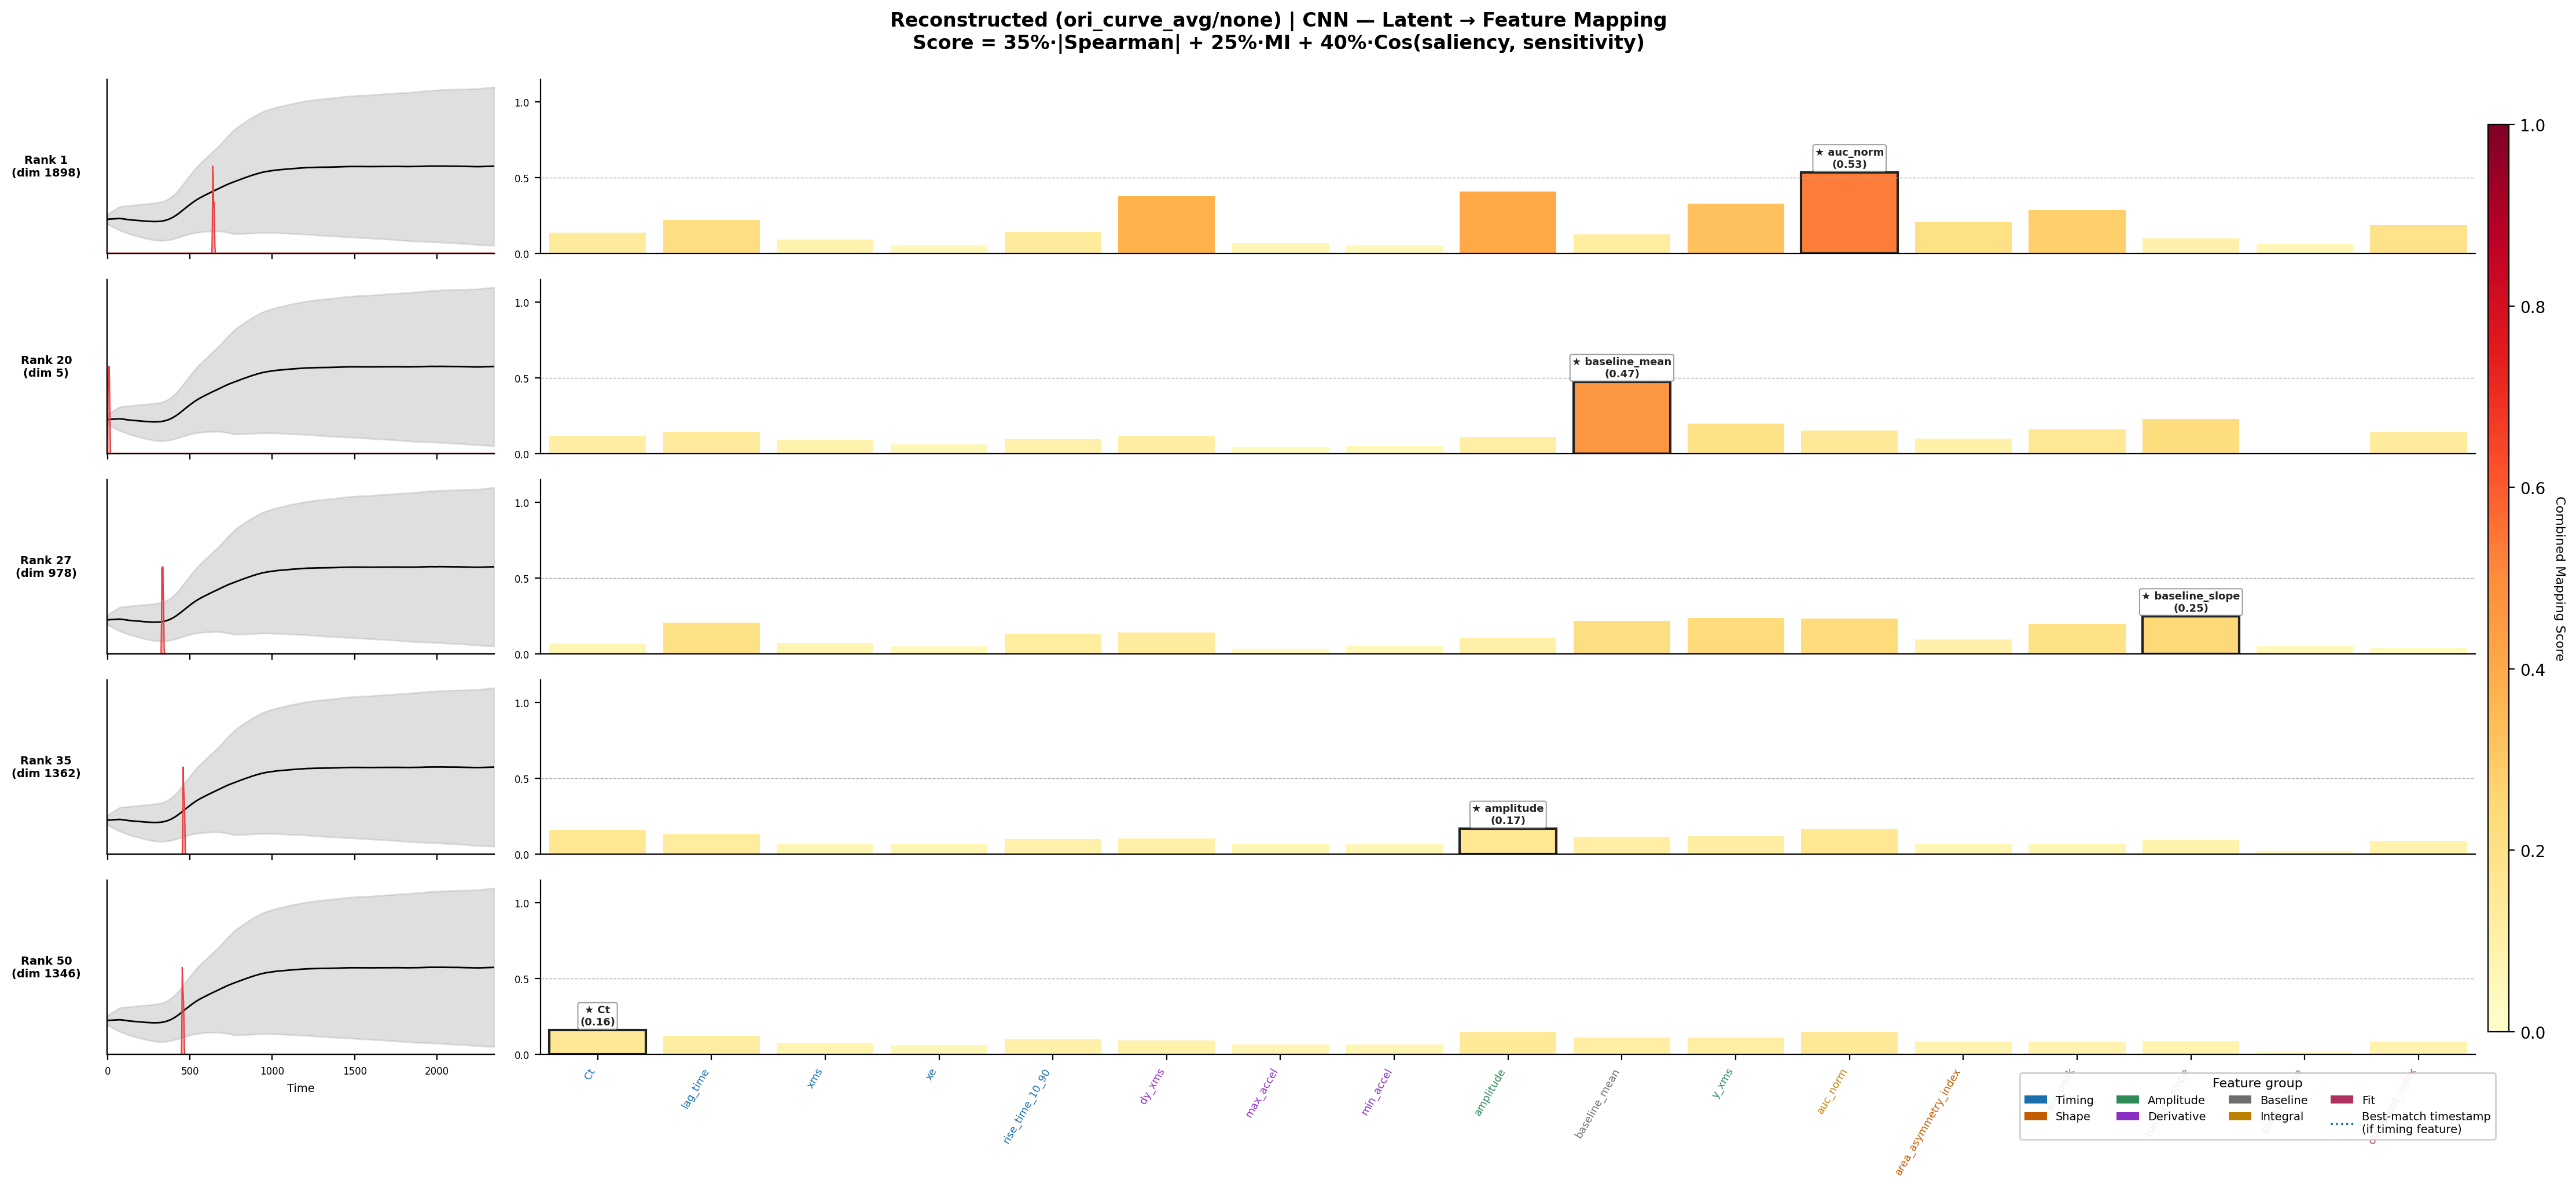

In [ ]:
cm = curve_meta[CURVE_TYPE]
sections = rebuild_sections(scores_df, profiles_df, cm["feat_names"], MODEL, FILTER, CURVE_TYPE)

save_path = f"/tmp/reconstructed_{MODEL}_{FILTER}_{CURVE_TYPE}.png"
render_latent_feature_mapping_figure(
    sections, cm["mean_curve"], cm["std_curve"], cm["timestamps"], cm["feat_names"],
    MODEL, f"Reconstructed ({CURVE_TYPE}/{FILTER})", save_path,
    # feat_matrix intentionally omitted -- not persisted, so the dotted timing-marker
    # line is the one thing that won't reappear; everything else matches exactly.
)
display(Image(filename=save_path))

### Switching which similarity metric drives the chart

`render_latent_feature_mapping_figure` takes a `metric=` parameter: `"combined"` (default, the
existing weighted blend), `"spearman"`, `"mi"` (normalized, same 0-1 scale as the others), or
`"cosine"`. The set of latents shown doesn't change (that selection is baked into `sections` via
the original `combined`-based ranking) — only which score is plotted in the bar chart, and which
feature gets the ★ best-match highlight for each shown latent, changes per metric.

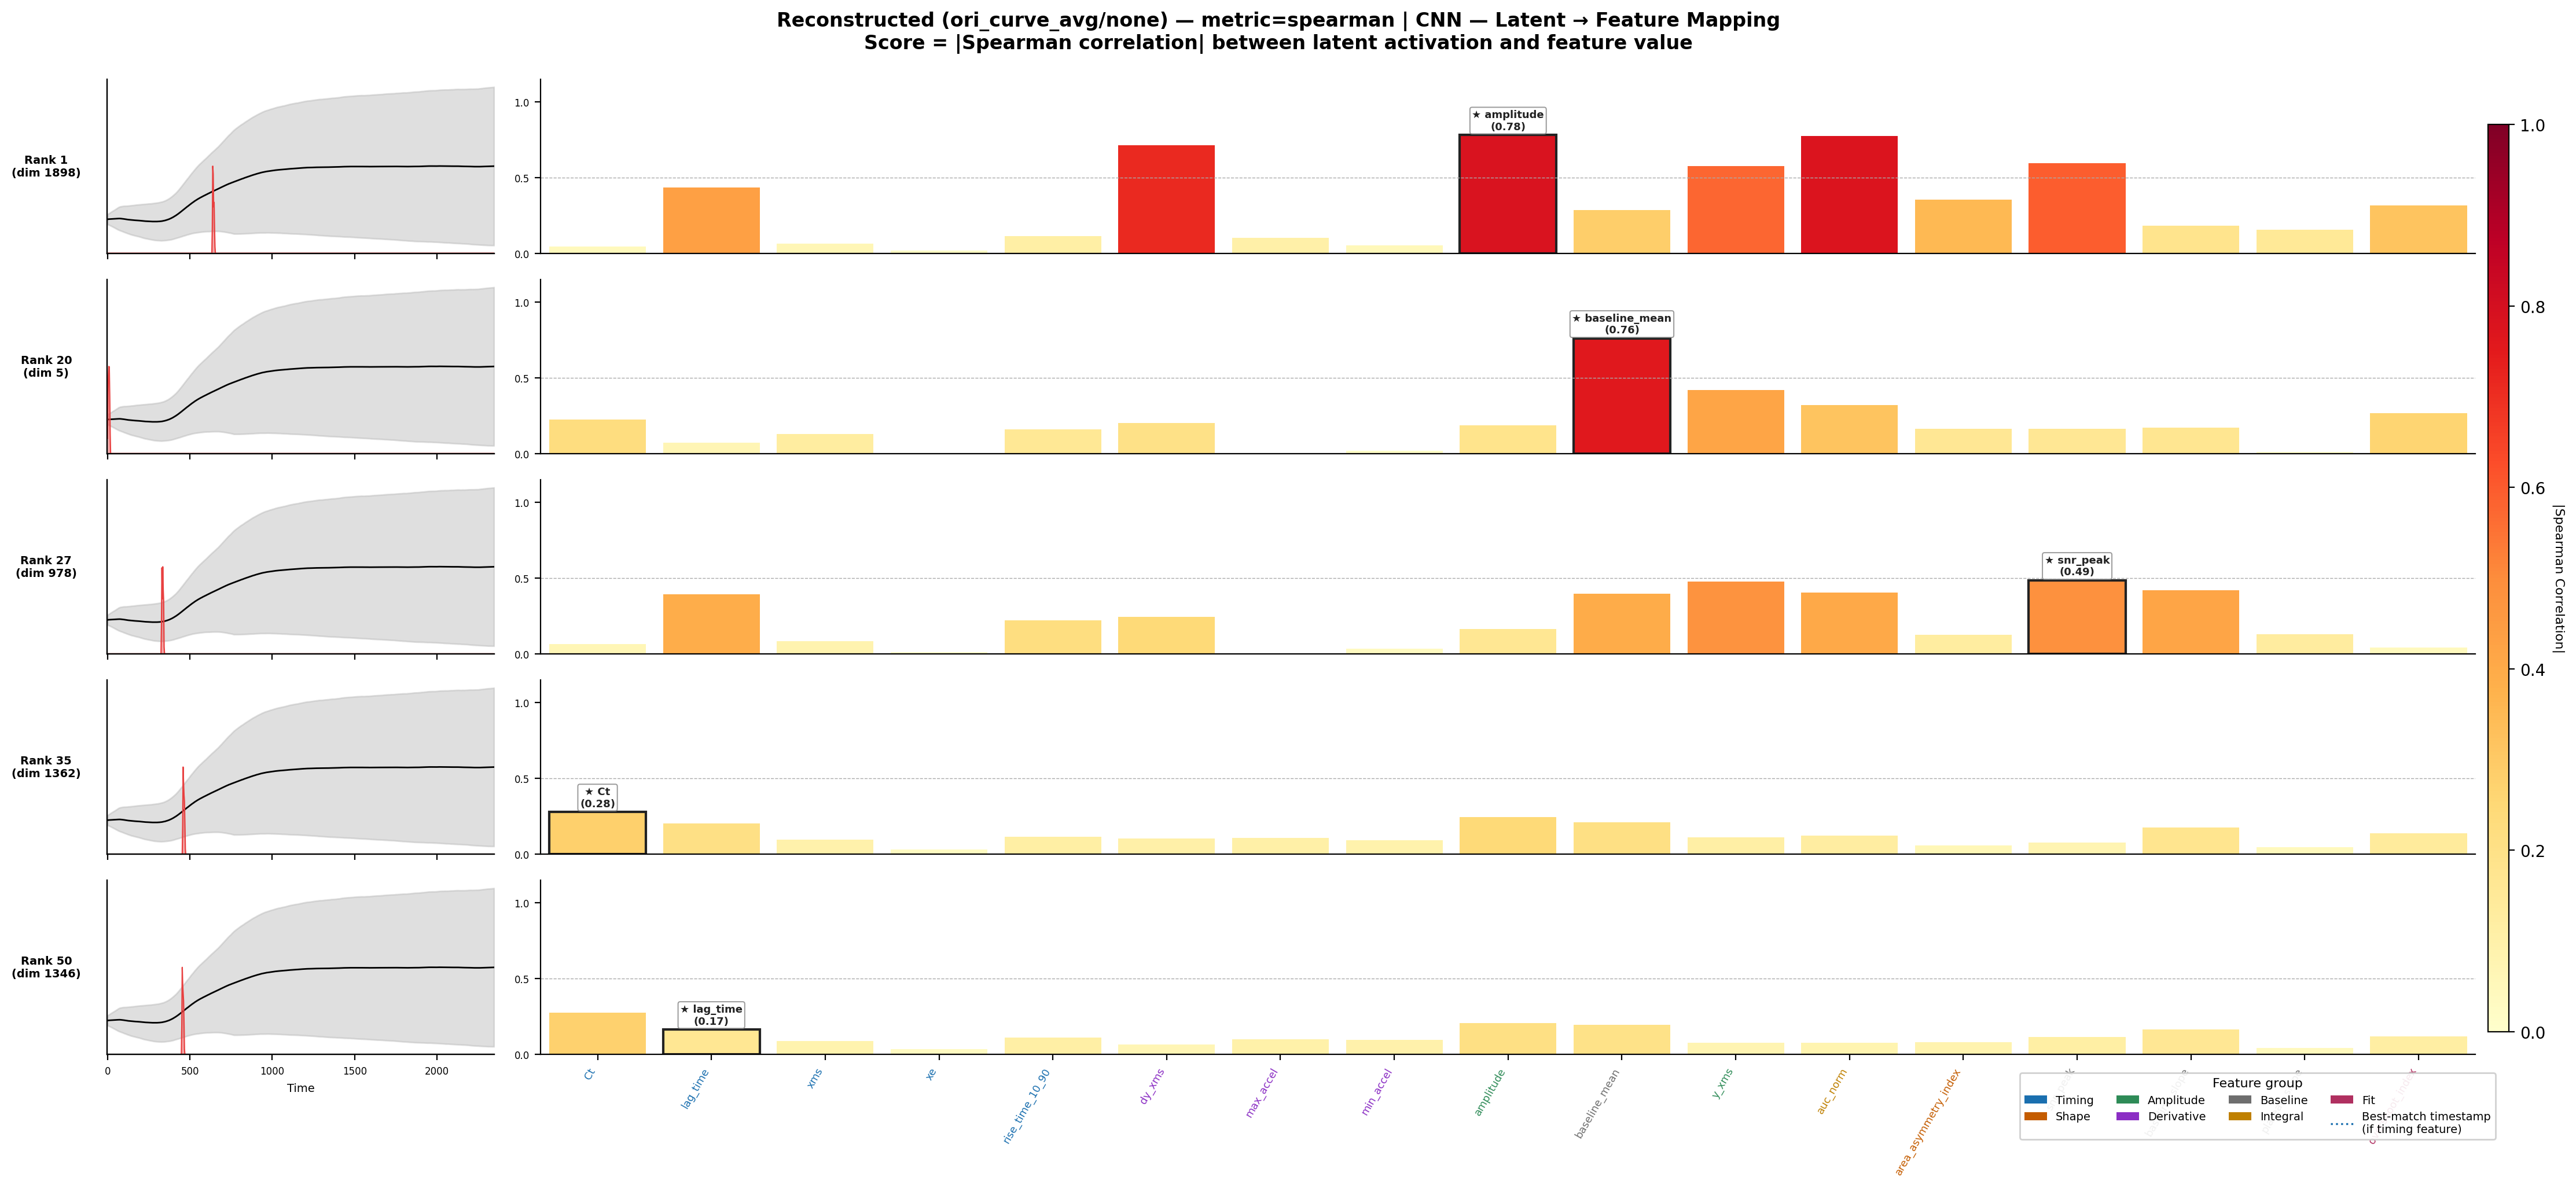

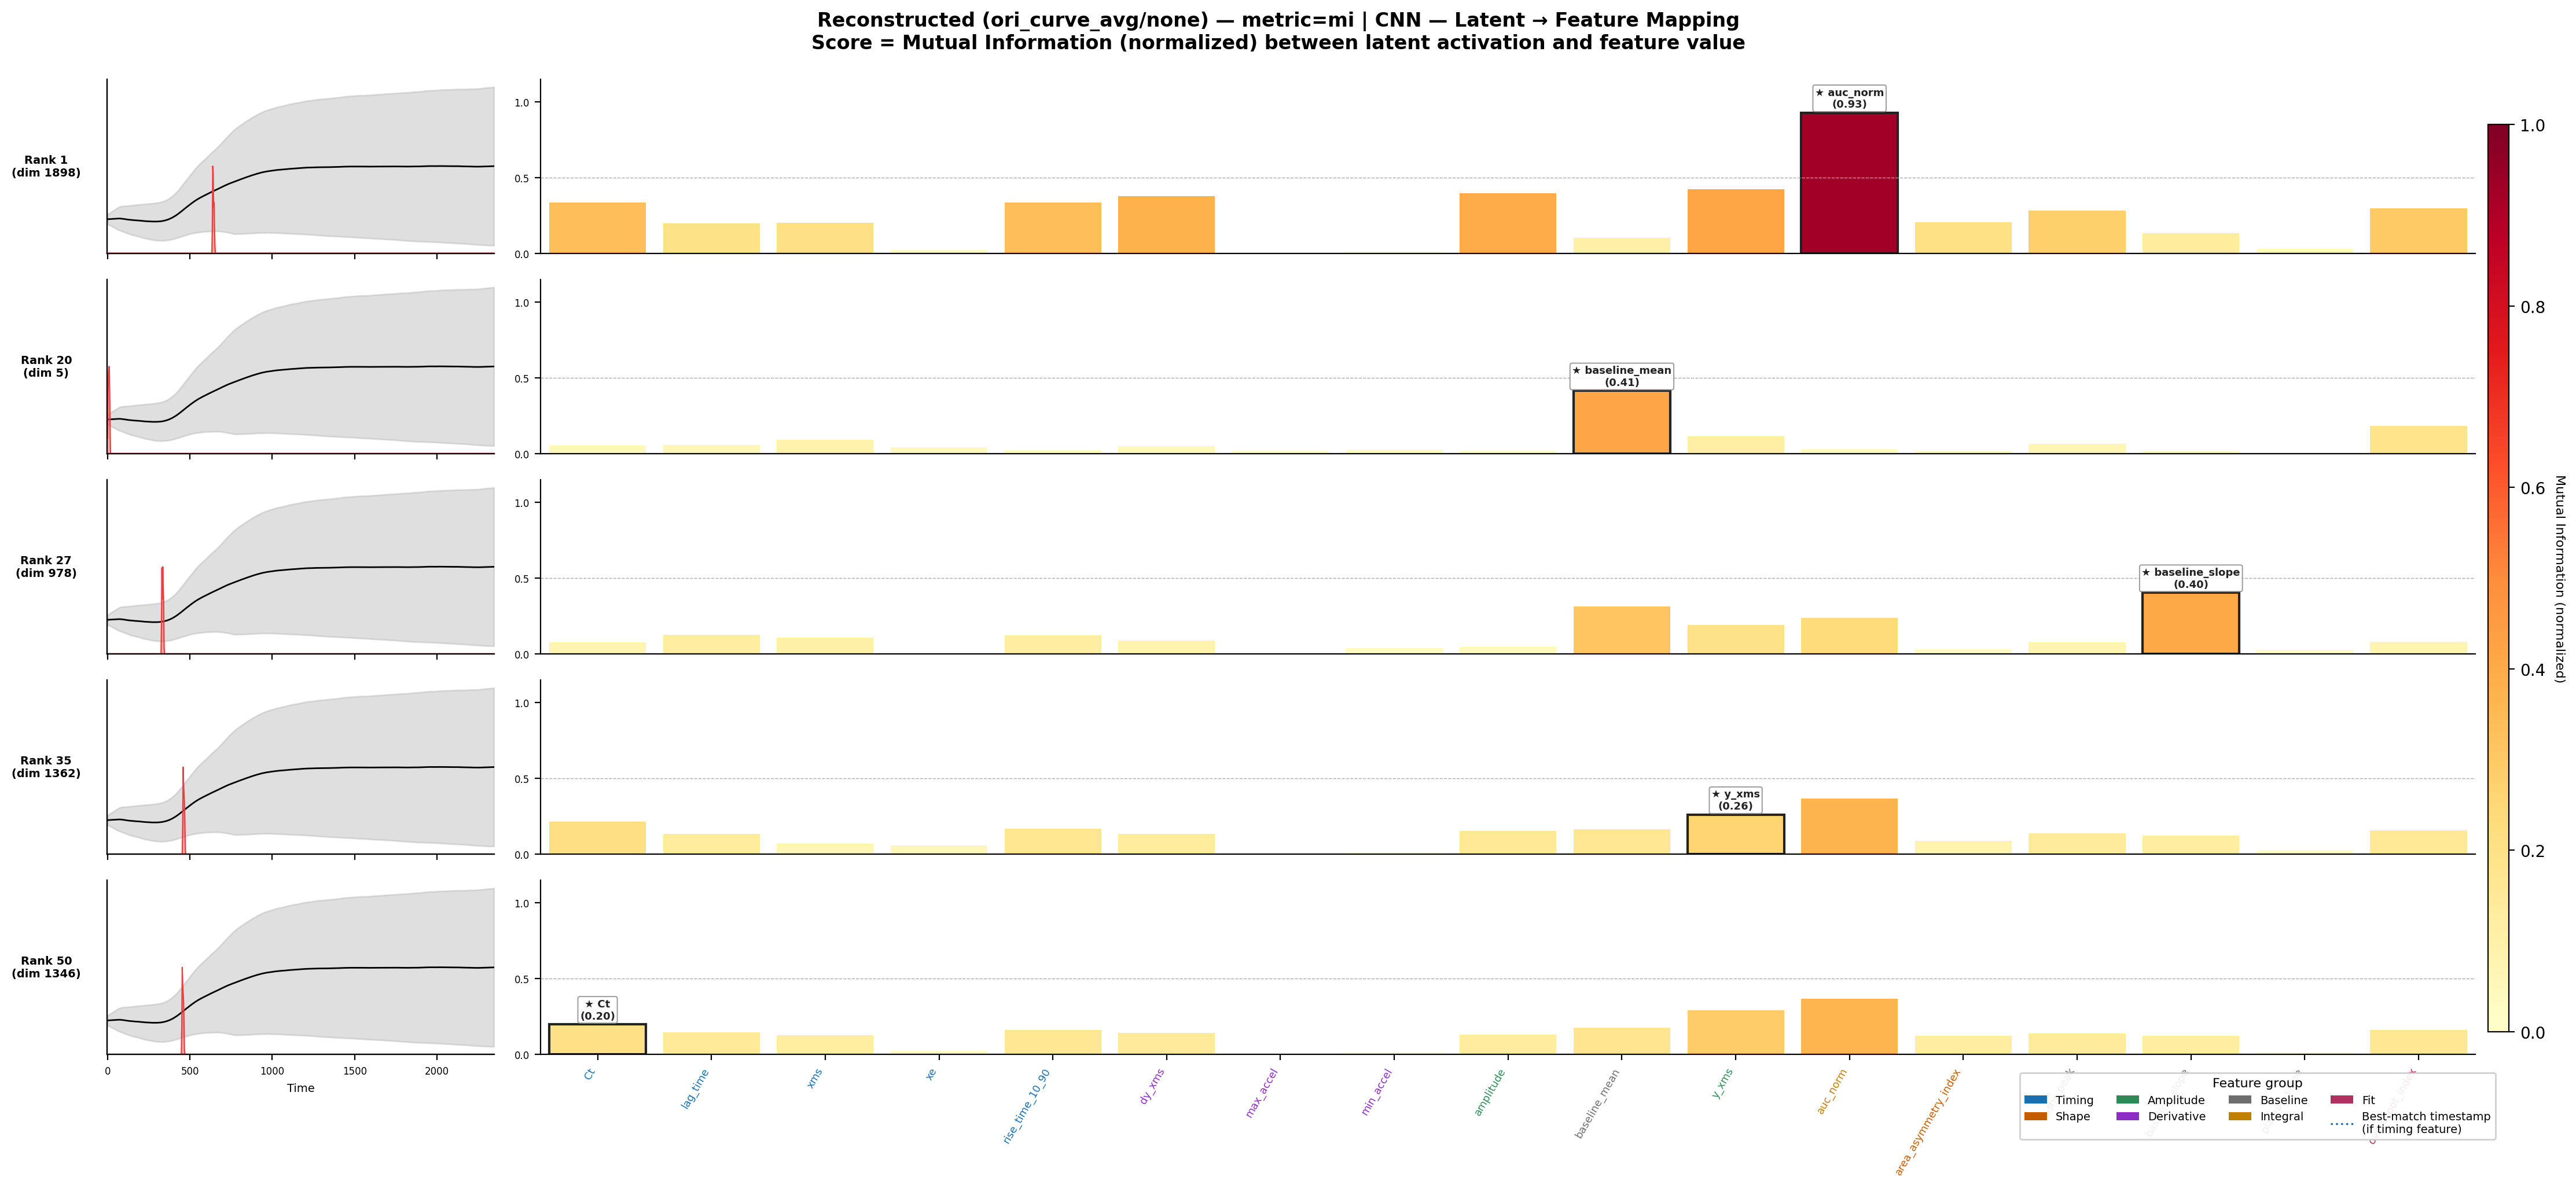

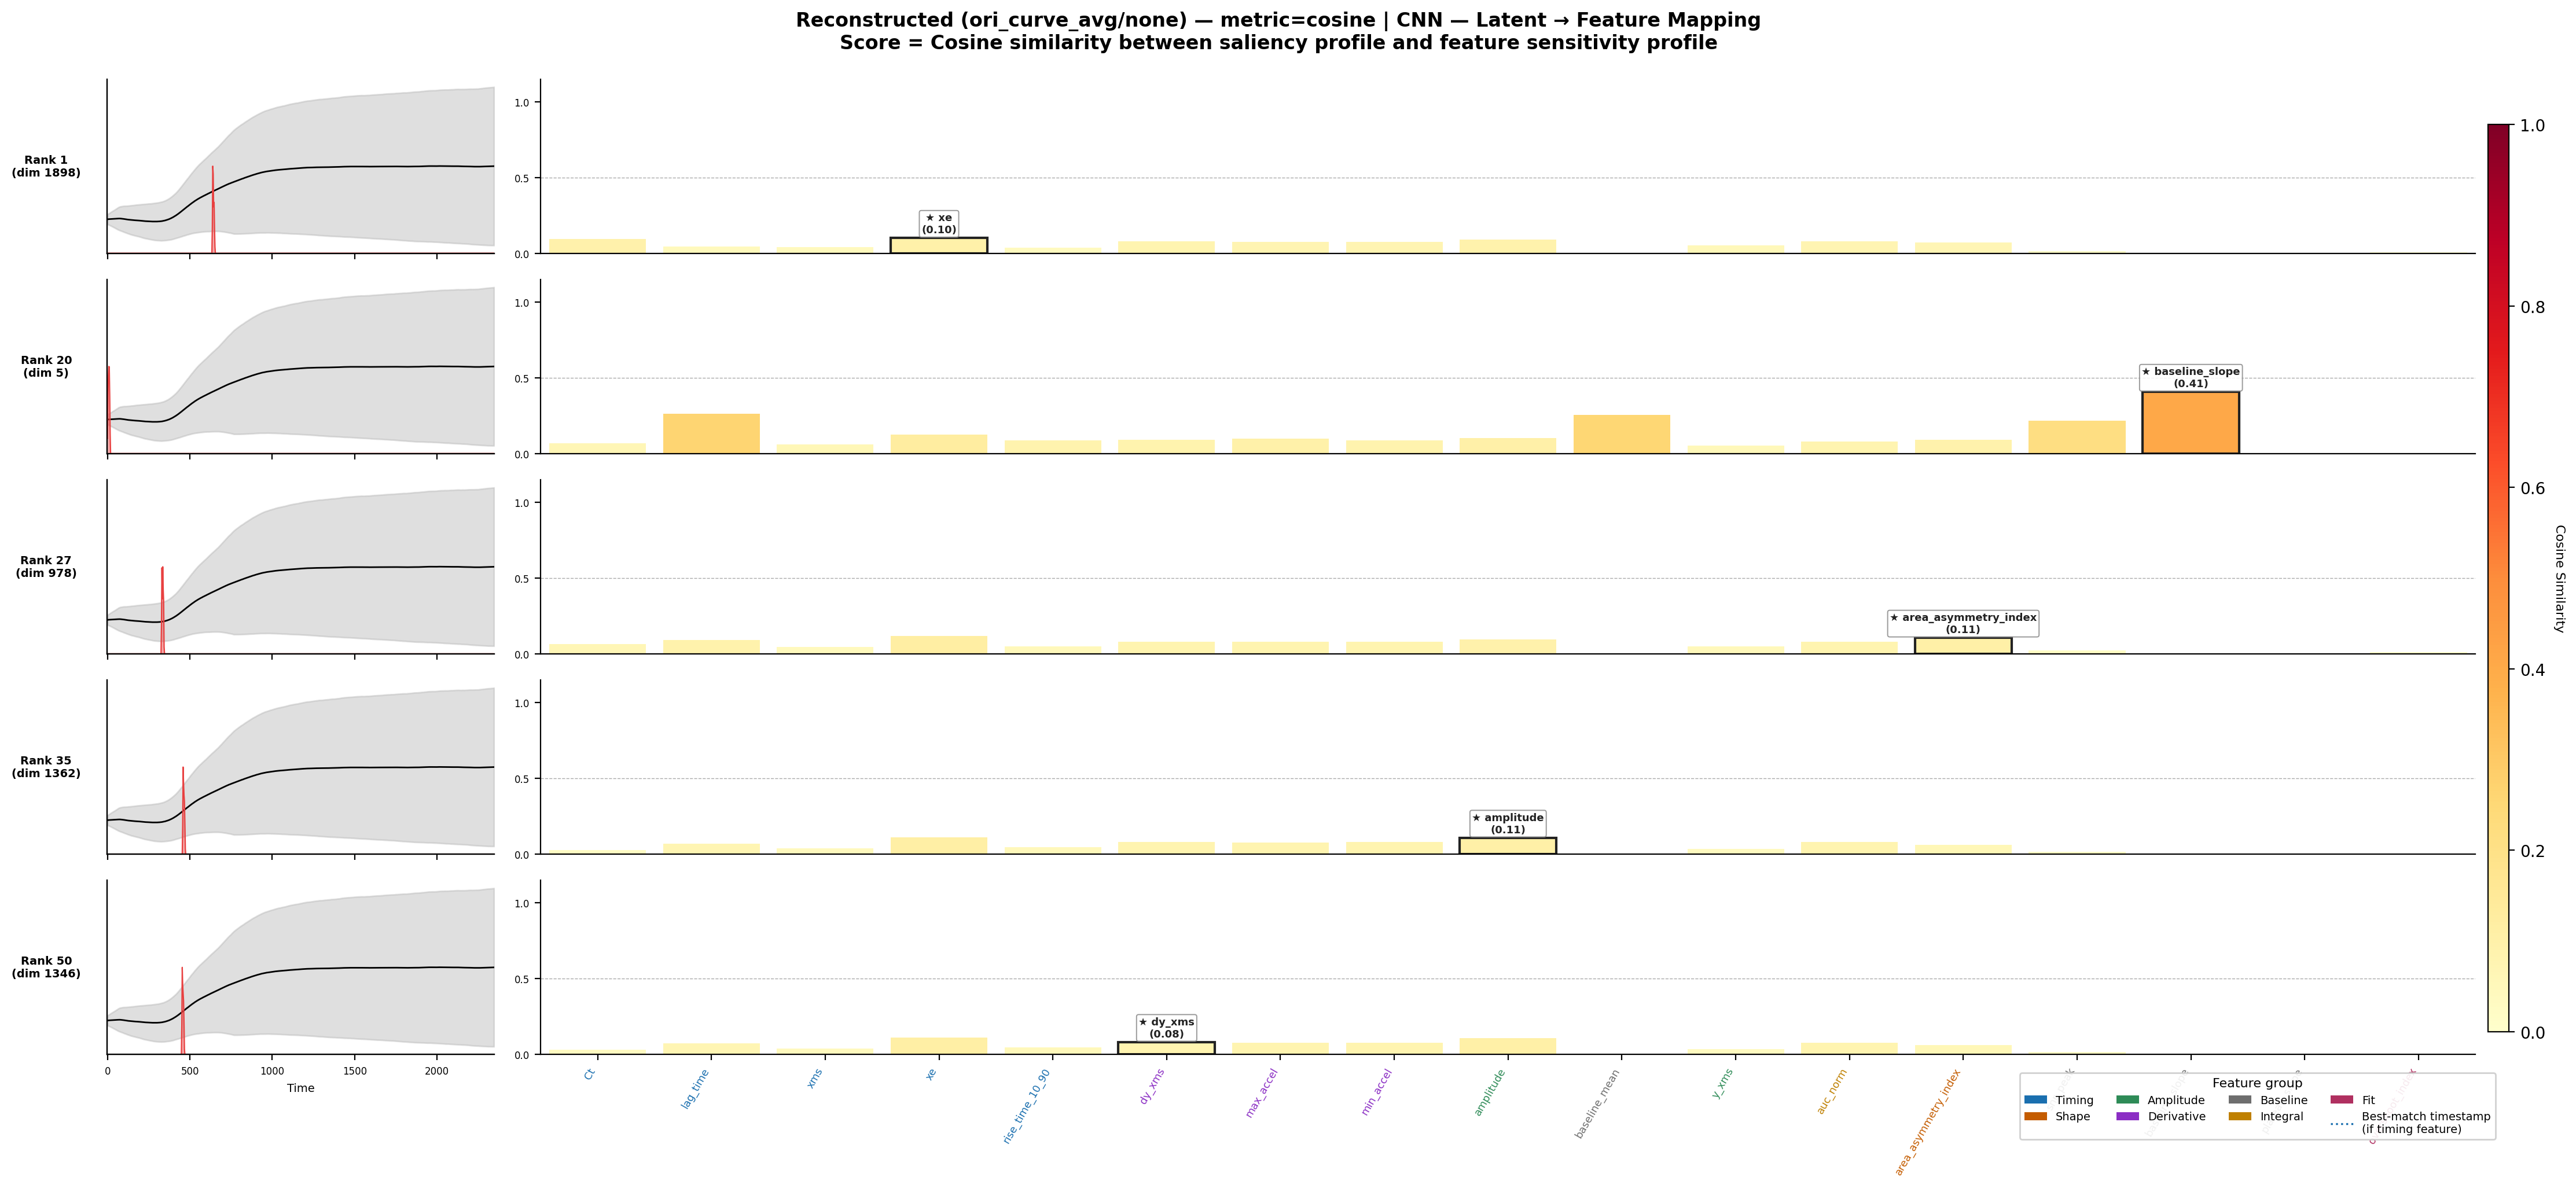

In [ ]:
for metric in ["spearman", "mi", "cosine"]:
    metric_save_path = f"/tmp/reconstructed_{MODEL}_{FILTER}_{CURVE_TYPE}_{metric}.png"
    render_latent_feature_mapping_figure(
        sections, cm["mean_curve"], cm["std_curve"], cm["timestamps"], cm["feat_names"],
        MODEL, f"Reconstructed ({CURVE_TYPE}/{FILTER}) — metric={metric}", metric_save_path,
        metric=metric,
    )
    display(Image(filename=metric_save_path))

## 4. Reconstruct for a 07b (cross-dataset LOFO) bundle

Same function, same schema — just pass `group_name`/`fold_label` too, since 07b's tables carry those
extra identifying columns that 07's don't need (one 07 file already = one experiment).

In [14]:
# Example -- adjust to a real group/fold/curve_type combination you've actually run 07b on.
GROUP_NAME = "CHANGE_ME"
FOLD_LABEL = "CHANGE_ME"
B_CURVE_TYPE = "ori_curve"

b_scores_path = (
    Path(config.MULTI_EXP_FOLDER) / "cross_dataset_cv" / GROUP_NAME / "model_interpretation"
    / FOLD_LABEL / f"latent_feature_scores_{B_CURVE_TYPE}.joblib"
)
print(b_scores_path)

# b_bundle = joblib.load(b_scores_path)
# b_scores_df, b_profiles_df, b_curve_meta = b_bundle["scores"], b_bundle["profiles"], b_bundle["curve_meta"]
# b_model = b_scores_df['model_name'].iloc[0]
# b_filter = b_scores_df['filter_key'].iloc[0]
# b_cm = b_curve_meta[B_CURVE_TYPE]
# b_sections = rebuild_sections(
#     b_scores_df, b_profiles_df, b_cm["feat_names"], b_model, b_filter, B_CURVE_TYPE,
#     group_name=GROUP_NAME, fold_label=FOLD_LABEL,
# )
# render_latent_feature_mapping_figure(
#     b_sections, b_cm["mean_curve"], b_cm["std_curve"], b_cm["timestamps"], b_cm["feat_names"],
#     b_model, f"{GROUP_NAME} | {FOLD_LABEL}", "/tmp/reconstructed_07b.png",
# )
# display(Image(filename="/tmp/reconstructed_07b.png"))

/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi/cross_dataset_cv/CHANGE_ME/model_interpretation/CHANGE_ME/latent_feature_scores_ori_curve.joblib
